# 07 — Récapitulatif des Résultats

Visualisation complète de l'évolution RMSE pour FR et UK.
**Aucun calcul** — uniquement lecture des résultats sauvegardés.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

---
## 1. Chargement des résultats

In [2]:
with open('../outputs/advanced_proxy_results.json') as f:
    proxy_results = json.load(f)

with open('../outputs/basis_modeling_results.json') as f:
    basis_results = json.load(f)

with open('../outputs/catboost_sweep_results.json') as f:
    sweep_results = json.load(f)

with open('../outputs/catboost_optuna_results.json') as f:
    optuna_results = json.load(f)

with open('../outputs/hyperparam_tuning_v1_fr.json') as f:
    hp_fr = json.load(f)

with open('../outputs/uk_tuning_v1.json') as f:
    uk_tuning = json.load(f)

with open('../outputs/final_pipeline_results.json') as f:
    final = json.load(f)

with open('../outputs/feature_discovery_v6.json') as f:
    discovery_v6 = json.load(f)

print('All results loaded.')

All results loaded.


---
## 2. FR — Évolution RMSE

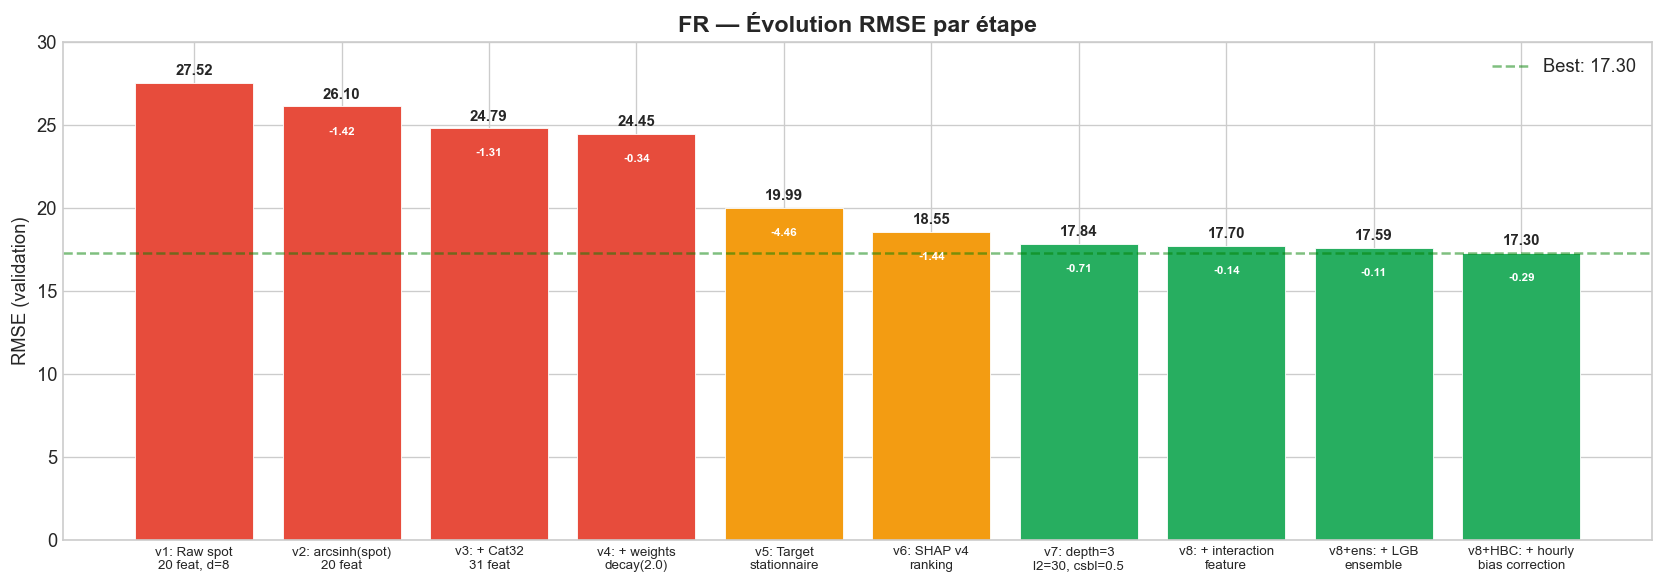


Total FR improvement: 27.52 → 17.30 = -10.22 (-37.1%)


In [3]:
# FR evolution: each step with its RMSE
fr_steps = [
    ('v1: Raw spot\n20 feat, d=8', 27.52),
    ('v2: arcsinh(spot)\n20 feat', 26.10),
    ('v3: + Cat32\n31 feat', 24.79),
    ('v4: + weights\ndecay(2.0)', 24.45),
    ('v5: Target\nstationnaire', 19.99),
    ('v6: SHAP v4\nranking', 18.55),
    ('v7: depth=3\nl2=30, csbl=0.5', 17.84),
    ('v8: + interaction\nfeature', 17.70),
    ('v8+ens: + LGB\nensemble', 17.59),
    ('v8+HBC: + hourly\nbias correction', 17.30),
]

labels, values = zip(*fr_steps)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#e74c3c' if v > 20 else '#f39c12' if v > 18 else '#27ae60' for v in values]
bars = ax.bar(range(len(values)), values, color=colors, edgecolor='white', linewidth=0.5)

# Add value labels on bars
for i, (bar, v) in enumerate(zip(bars, values)):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v:.2f}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)
    # Delta annotation
    if i > 0:
        delta = v - values[i-1]
        ax.text(bar.get_x() + bar.get_width()/2, v - 1.2, f'{delta:+.2f}',
                ha='center', va='top', fontsize=7, color='white', fontweight='bold')

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('RMSE (validation)')
ax.set_title('FR — Évolution RMSE par étape', fontsize=14, fontweight='bold')
ax.set_ylim(0, 30)
ax.axhline(y=17.30, color='green', linestyle='--', alpha=0.5, label='Best: 17.30')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/fr_rmse_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal FR improvement: {values[0]:.2f} → {values[-1]:.2f} = {values[-1]-values[0]:+.2f} ({(values[-1]-values[0])/values[0]*100:+.1f}%)')

### 2.1 FR — Décomposition des gains

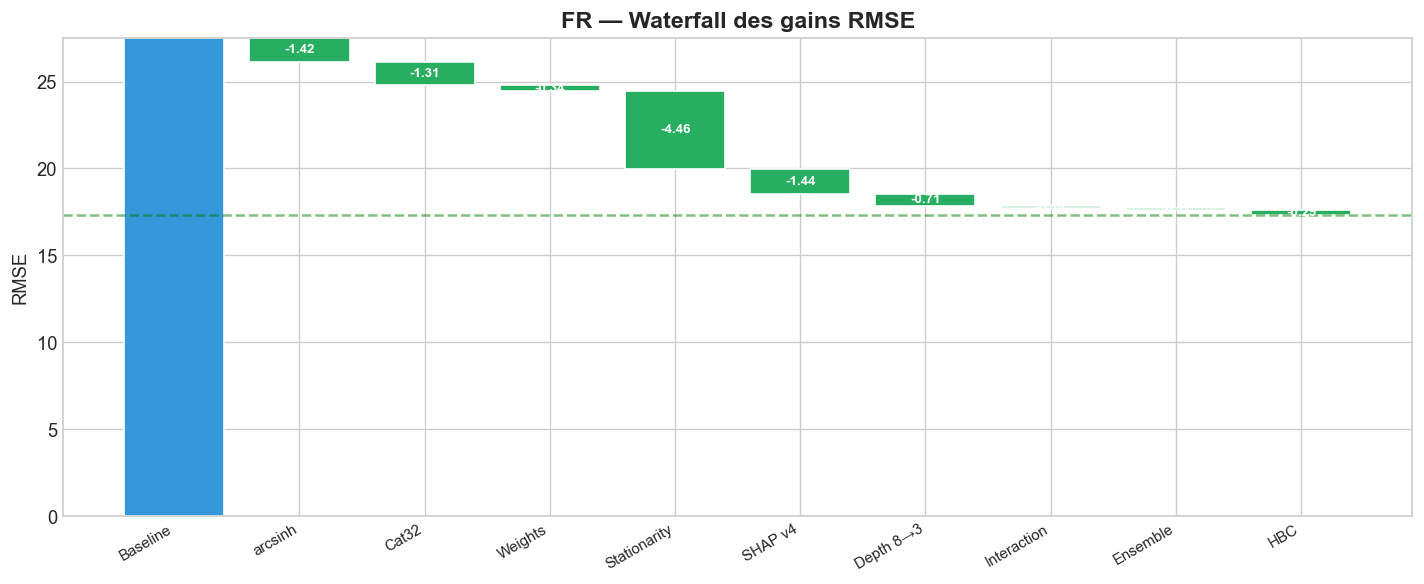


Top 3 gains FR:
  Stationarity        : -4.46
  SHAP v4             : -1.44
  arcsinh             : -1.42


In [4]:
# Waterfall chart of FR gains
gain_labels = [
    'Baseline', 'arcsinh', 'Cat32', 'Weights', 'Stationarity',
    'SHAP v4', 'Depth 8→3', 'Interaction', 'Ensemble', 'HBC'
]
gain_values = [values[0]] + [values[i] - values[i-1] for i in range(1, len(values))]

fig, ax = plt.subplots(figsize=(12, 5))
cumulative = 0
for i, (label, val) in enumerate(zip(gain_labels, gain_values)):
    if i == 0:
        ax.bar(i, val, color='#3498db', edgecolor='white')
        cumulative = val
    else:
        color = '#27ae60' if val < 0 else '#e74c3c'
        ax.bar(i, val, bottom=cumulative, color=color, edgecolor='white')
        ax.text(i, cumulative + val/2, f'{val:+.2f}', ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')
        cumulative += val

ax.set_xticks(range(len(gain_labels)))
ax.set_xticklabels(gain_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('RMSE')
ax.set_title('FR — Waterfall des gains RMSE', fontsize=14, fontweight='bold')
ax.axhline(y=17.30, color='green', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('\nTop 3 gains FR:')
sorted_gains = sorted(zip(gain_labels[1:], gain_values[1:]), key=lambda x: x[1])
for label, val in sorted_gains[:3]:
    print(f'  {label:20s}: {val:+.2f}')

### 2.2 FR — Sensibilité aux hyperparamètres

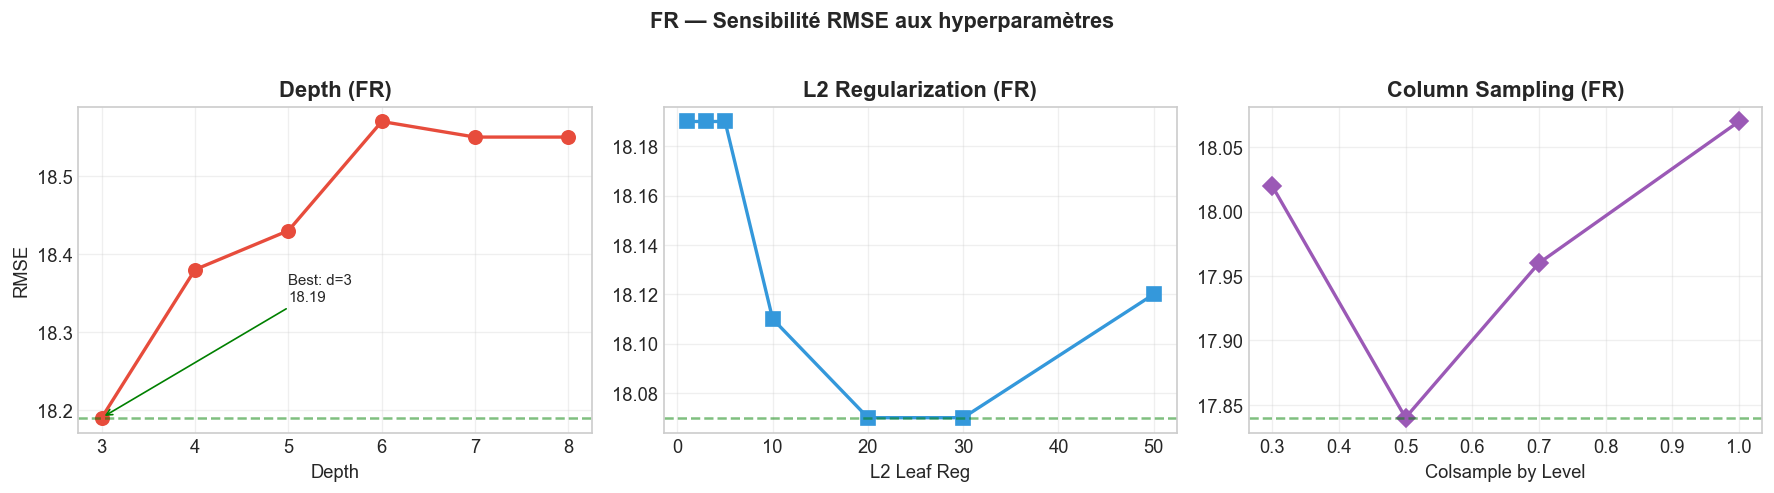

In [5]:
# FR HP sensitivity from tuning results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Depth impact (from hyperparam_tuning_v1 output)
depths =    [3,     4,     5,     6,     7,     8]
rmse_depth = [18.19, 18.38, 18.43, 18.57, 18.55, 18.55]  # from tuning v1 stage B
axes[0].plot(depths, rmse_depth, 'o-', color='#e74c3c', linewidth=2, markersize=8)
axes[0].set_xlabel('Depth')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Depth (FR)', fontweight='bold')
axes[0].axhline(y=min(rmse_depth), color='green', linestyle='--', alpha=0.5)
axes[0].annotate(f'Best: d={depths[rmse_depth.index(min(rmse_depth))]}\n{min(rmse_depth):.2f}',
                 xy=(depths[rmse_depth.index(min(rmse_depth))], min(rmse_depth)),
                 xytext=(5, min(rmse_depth)+0.15), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='green'))

# L2 impact
l2s =       [1,     3,     5,     10,    20,    30,    50]
rmse_l2 =   [18.19, 18.19, 18.19, 18.11, 18.07, 18.07, 18.12]  # from tuning v1 stage D
axes[1].plot(l2s, rmse_l2, 's-', color='#3498db', linewidth=2, markersize=8)
axes[1].set_xlabel('L2 Leaf Reg')
axes[1].set_title('L2 Regularization (FR)', fontweight='bold')
axes[1].axhline(y=min(rmse_l2), color='green', linestyle='--', alpha=0.5)

# Colsample impact
csbl =        [0.3,   0.5,   0.7,   1.0]
rmse_csbl =   [18.02, 17.84, 17.96, 18.07]  # from tuning v1 stage E
axes[2].plot(csbl, rmse_csbl, 'D-', color='#9b59b6', linewidth=2, markersize=8)
axes[2].set_xlabel('Colsample by Level')
axes[2].set_title('Column Sampling (FR)', fontweight='bold')
axes[2].axhline(y=min(rmse_csbl), color='green', linestyle='--', alpha=0.5)

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle('FR — Sensibilité RMSE aux hyperparamètres', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/fr_hp_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 FR — HBC (Hourly Bias Correction)

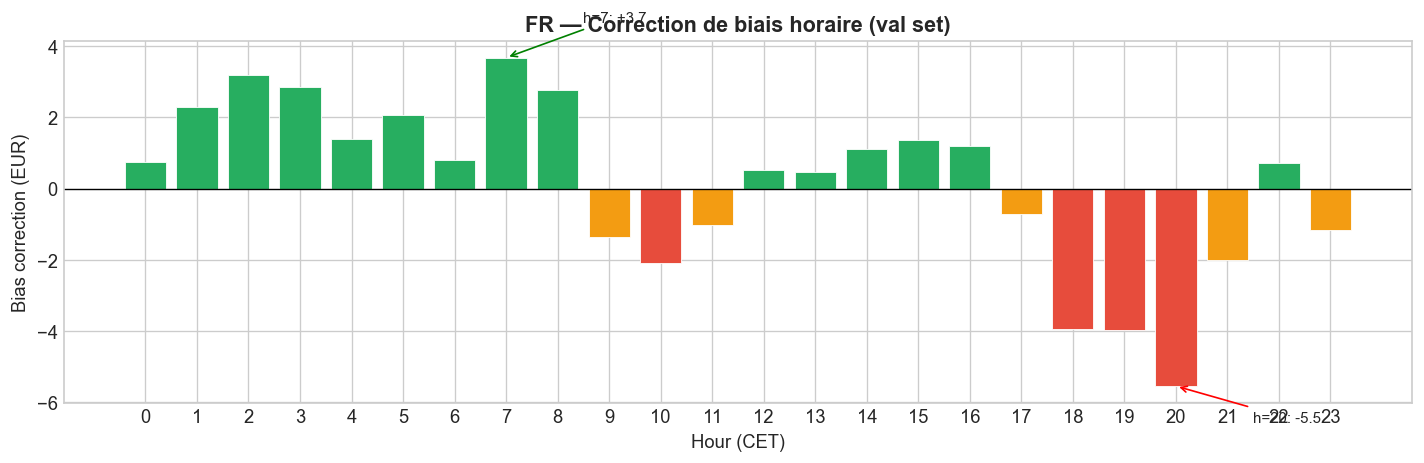

HBC impact FR: 17.70 → 17.44 (CatBoost seul), 17.59 → 17.30 (ensemble)
Mean abs bias: 1.96 EUR
Worst hours: h=18 (-3.9), h=10 (-2.1), h=17 (-0.7)


In [6]:
# FR Hourly Bias Correction
hbc_fr = final['hbc_fr']
hours = list(range(24))
biases_fr = [hbc_fr[str(h)] for h in hours]

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#e74c3c' if b < -2 else '#f39c12' if b < 0 else '#27ae60' for b in biases_fr]
ax.bar(hours, biases_fr, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xlabel('Hour (CET)')
ax.set_ylabel('Bias correction (EUR)')
ax.set_title('FR — Correction de biais horaire (val set)', fontsize=13, fontweight='bold')
ax.set_xticks(hours)

# Annotate extremes
h_min = hours[np.argmin(biases_fr)]
h_max = hours[np.argmax(biases_fr)]
ax.annotate(f'h={h_min}: {biases_fr[h_min]:+.1f}', xy=(h_min, biases_fr[h_min]),
            xytext=(h_min+1.5, biases_fr[h_min]-1), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='red'))
ax.annotate(f'h={h_max}: {biases_fr[h_max]:+.1f}', xy=(h_max, biases_fr[h_max]),
            xytext=(h_max+1.5, biases_fr[h_max]+1), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()
plt.show()

print(f'HBC impact FR: 17.70 → 17.44 (CatBoost seul), 17.59 → 17.30 (ensemble)')
print(f'Mean abs bias: {np.mean(np.abs(biases_fr)):.2f} EUR')
print(f'Worst hours: h=18 ({biases_fr[18]:+.1f}), h=10 ({biases_fr[10]:+.1f}), h=17 ({biases_fr[17]:+.1f})')

### 2.4 FR — Feature count vs RMSE

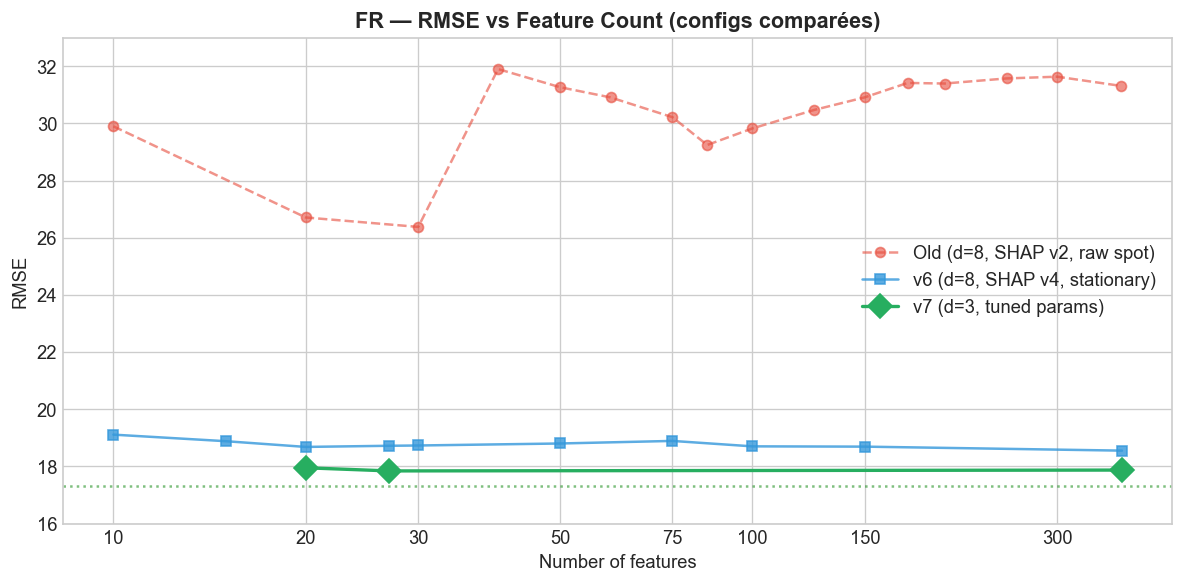

In [7]:
# FR feature count vs RMSE (from sweep results, different configs)
# Old config (d=8, raw SHAP v2)
sweep_fr = [(r['n_features'], r['rmse']) for r in sweep_results if r['target'] == 'fr_spot']
sweep_fr.sort()
n_old, rmse_old = zip(*sweep_fr)

# New config results from feature_selection_v5 + discovery_v6
# v5 sweep: top-N with v7 params
n_new =    [10,    15,    20,    27,    30,    50,    75,    100,   150,   379]
rmse_new = [19.11, 18.88, 18.68, 18.72, 18.73, 18.80, 18.89, 18.70, 18.69, 18.55]  # v6 params
# With v7 tuned params:
rmse_v7 =  [None,  None,  17.95, 17.84, None,  None,  None,  None,  None,  17.87]  # from final

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_old, rmse_old, 'o--', color='#e74c3c', alpha=0.6, label='Old (d=8, SHAP v2, raw spot)', markersize=6)
ax.plot(n_new, rmse_new, 's-', color='#3498db', alpha=0.8, label='v6 (d=8, SHAP v4, stationary)', markersize=6)

# v7 points
n_v7 = [n for n, r in zip(n_new, rmse_v7) if r is not None]
r_v7 = [r for r in rmse_v7 if r is not None]
ax.plot(n_v7, r_v7, 'D-', color='#27ae60', markersize=10, linewidth=2, label='v7 (d=3, tuned params)')

ax.set_xlabel('Number of features')
ax.set_ylabel('RMSE')
ax.set_title('FR — RMSE vs Feature Count (configs comparées)', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([10, 20, 30, 50, 75, 100, 150, 300])
ax.set_ylim(16, 33)
ax.axhline(y=17.30, color='green', linestyle=':', alpha=0.5, label='Best w/ ens+HBC')
plt.tight_layout()
plt.savefig('../outputs/fr_feat_vs_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. UK — Évolution RMSE

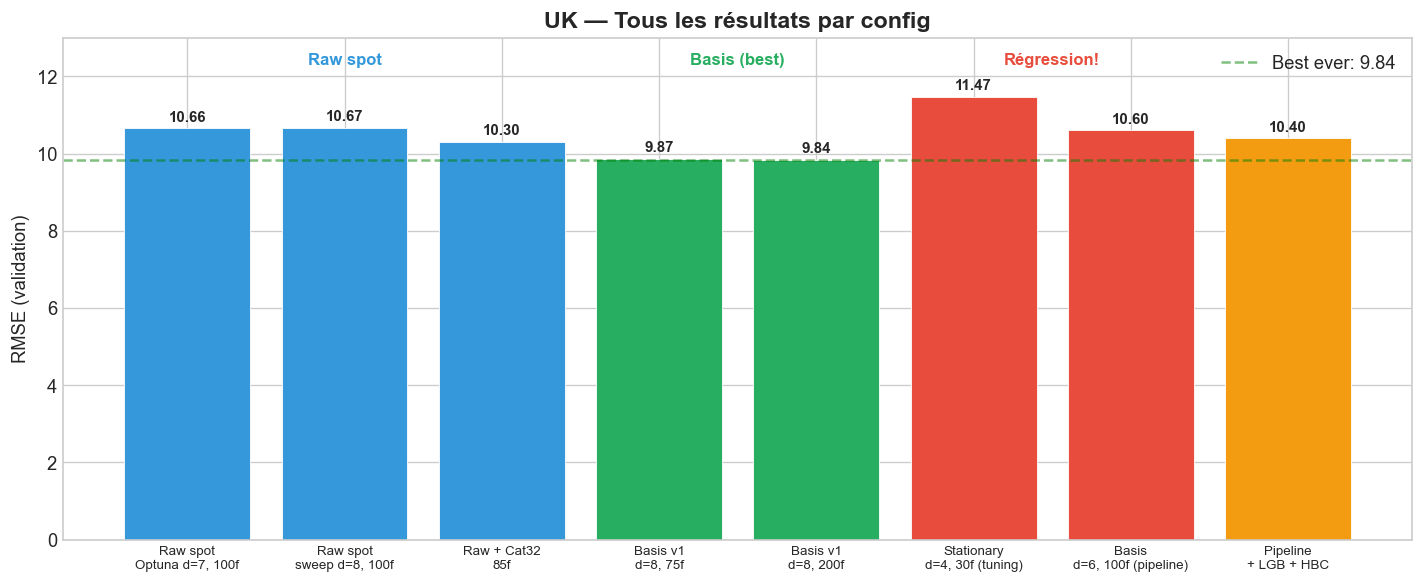

In [8]:
# UK: All results from different experiments
uk_configs = [
    # (label, rmse, source)
    ('Raw spot\nOptuna d=7, 100f', 10.66, 'optuna'),
    ('Raw spot\nsweep d=8, 100f', 10.67, 'sweep'),
    ('Raw + Cat32\n85f', 10.30, 'proxy F'),
    ('Basis v1\nd=8, 75f', 9.87, 'basis'),
    ('Basis v1\nd=8, 200f', 9.84, 'basis (best ever)'),
    ('Stationary\nd=4, 30f (tuning)', 11.47, 'uk_tuning (stat)'),
    ('Basis\nd=6, 100f (pipeline)', 10.60, 'final_pipeline'),
    ('Pipeline\n+ LGB + HBC', 10.40, 'final + post'),
]

fig, ax = plt.subplots(figsize=(12, 5))
labels_uk = [c[0] for c in uk_configs]
values_uk = [c[1] for c in uk_configs]
colors_uk = ['#3498db'] * 3 + ['#27ae60'] * 2 + ['#e74c3c'] * 2 + ['#f39c12']

bars = ax.bar(range(len(values_uk)), values_uk, color=colors_uk, edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, values_uk):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1, f'{v:.2f}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xticks(range(len(labels_uk)))
ax.set_xticklabels(labels_uk, fontsize=8)
ax.set_ylabel('RMSE (validation)')
ax.set_title('UK — Tous les résultats par config', fontsize=14, fontweight='bold')
ax.axhline(y=9.84, color='green', linestyle='--', alpha=0.5, label='Best ever: 9.84')
ax.set_ylim(0, 13)
ax.legend()

# Add category labels
ax.text(1, 12.3, 'Raw spot', ha='center', fontsize=10, color='#3498db', fontweight='bold')
ax.text(3.5, 12.3, 'Basis (best)', ha='center', fontsize=10, color='#27ae60', fontweight='bold')
ax.text(5.5, 12.3, 'Régression!', ha='center', fontsize=10, color='#e74c3c', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/uk_rmse_all_configs.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.1 UK — Feature count vs RMSE (basis modeling)

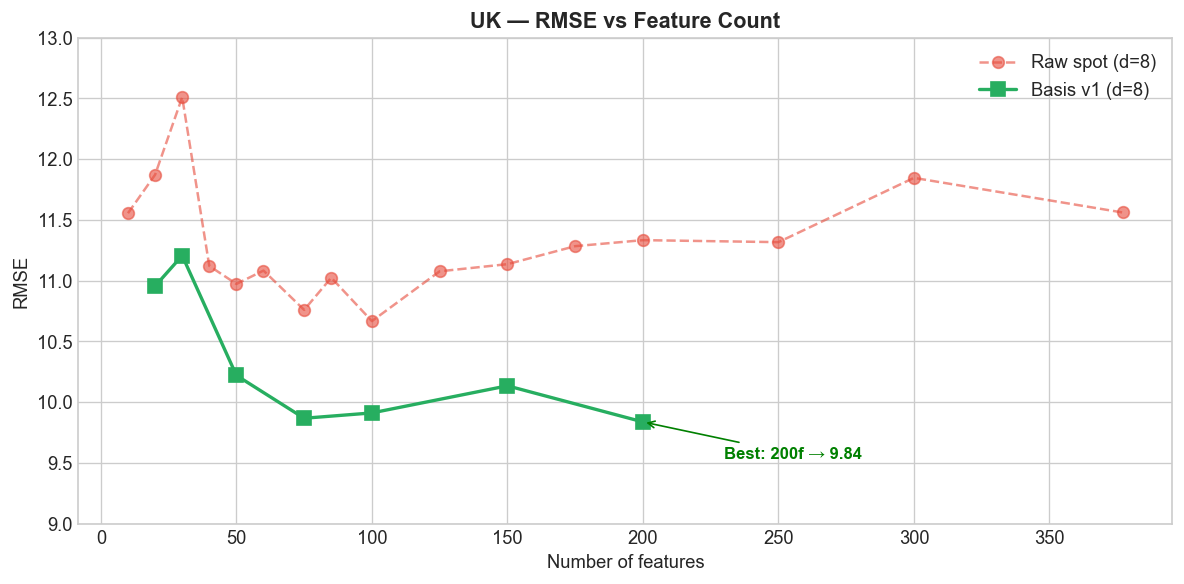

UK basis modeling: optimal at 200 features
UK raw spot: optimal at 100 features
→ UK needs MORE features than FR (27) — different dynamics


In [9]:
# UK basis sweep results
uk_basis_sweep = basis_results['step2_sweep']['uk_spot']['basis_raw']
n_basis = [int(k) for k in uk_basis_sweep.keys()]
rmse_basis = list(uk_basis_sweep.values())

# UK raw sweep results
sweep_uk = [(r['n_features'], r['rmse']) for r in sweep_results if r['target'] == 'uk_spot']
sweep_uk.sort()
n_raw, rmse_raw = zip(*sweep_uk)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_raw, rmse_raw, 'o--', color='#e74c3c', alpha=0.6, label='Raw spot (d=8)', markersize=7)
ax.plot(n_basis, rmse_basis, 's-', color='#27ae60', linewidth=2, markersize=8, label='Basis v1 (d=8)')

# Mark best
best_idx = np.argmin(rmse_basis)
ax.annotate(f'Best: {n_basis[best_idx]}f → {rmse_basis[best_idx]:.2f}',
            xy=(n_basis[best_idx], rmse_basis[best_idx]),
            xytext=(n_basis[best_idx]+30, rmse_basis[best_idx]-0.3),
            fontsize=10, fontweight='bold', color='green',
            arrowprops=dict(arrowstyle='->', color='green'))

ax.set_xlabel('Number of features')
ax.set_ylabel('RMSE')
ax.set_title('UK — RMSE vs Feature Count', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(9, 13)
plt.tight_layout()
plt.savefig('../outputs/uk_feat_vs_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

print('UK basis modeling: optimal at 200 features')
print('UK raw spot: optimal at 100 features')
print('→ UK needs MORE features than FR (27) — different dynamics')

### 3.2 UK — HBC (Hourly Bias Correction)

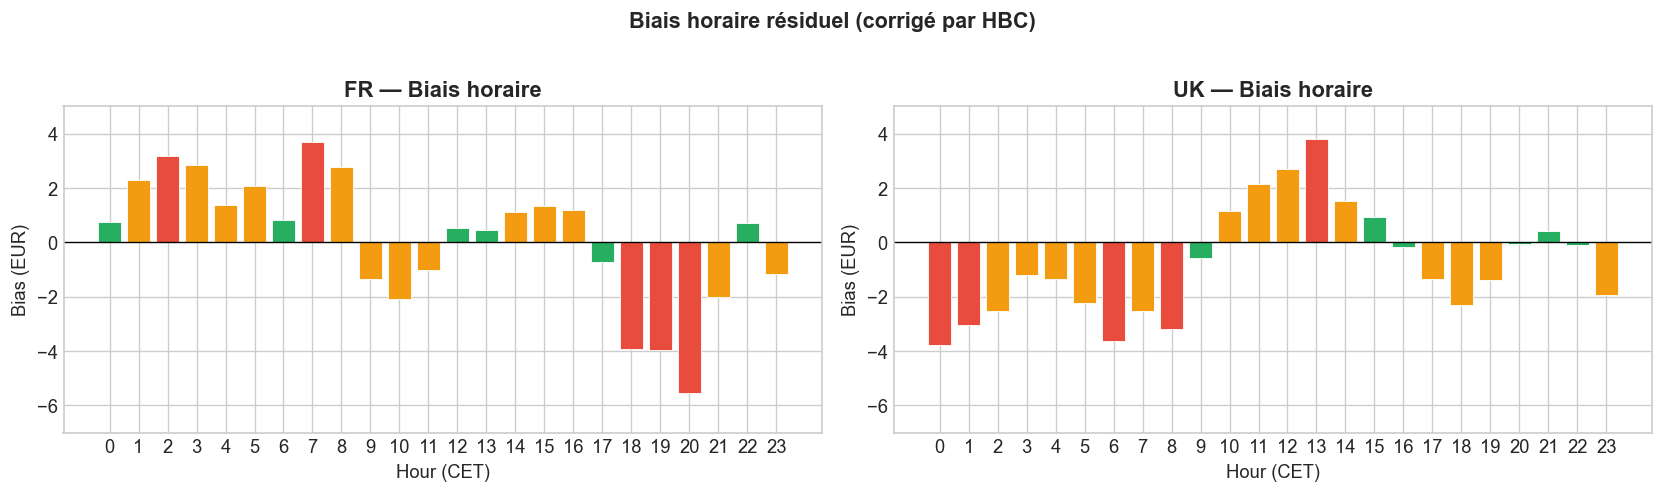

FR mean |bias|: 1.96 EUR — pattern: sous-prédit matin, sur-prédit soir
UK mean |bias|: 1.84 EUR — pattern: sur-prédit nuit, sous-prédit jour


In [10]:
# UK Hourly Bias
hbc_uk = final['hbc_uk']
biases_uk = [hbc_uk[str(h)] for h in hours]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, biases, title, target in [(axes[0], biases_fr, 'FR', 'fr'),
                                   (axes[1], biases_uk, 'UK', 'uk')]:
    colors = ['#e74c3c' if abs(b) > 3 else '#f39c12' if abs(b) > 1 else '#27ae60' for b in biases]
    ax.bar(hours, biases, color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_xlabel('Hour (CET)')
    ax.set_ylabel('Bias (EUR)')
    ax.set_title(f'{title} — Biais horaire', fontweight='bold')
    ax.set_xticks(hours)
    ax.set_ylim(-7, 5)

plt.suptitle('Biais horaire résiduel (corrigé par HBC)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/hbc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'FR mean |bias|: {np.mean(np.abs(biases_fr)):.2f} EUR — pattern: sous-prédit matin, sur-prédit soir')
print(f'UK mean |bias|: {np.mean(np.abs(biases_uk)):.2f} EUR — pattern: sur-prédit nuit, sous-prédit jour')

---
## 4. Combined — Vue d'ensemble

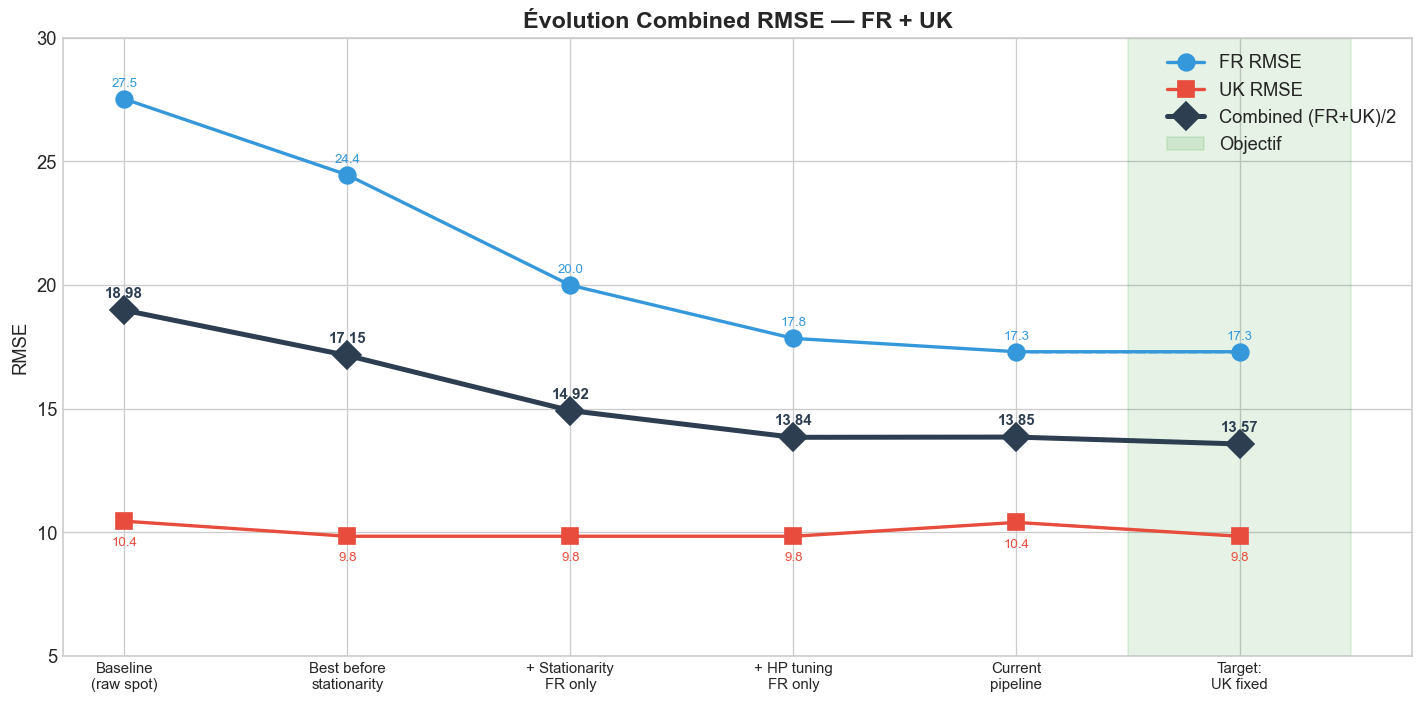


Problème visible: UK a régressé de 9.84 → 10.40 dans le pipeline final
Si on corrige UK: combined passerait de 13.85 → ~13.57


In [11]:
# Combined evolution
combined_history = [
    ('Baseline\n(raw spot)', 27.52, 10.45, 18.98),
    ('Best before\nstationarity', 24.45, 9.84, 17.15),
    ('+ Stationarity\nFR only', 19.99, 9.84, 14.92),
    ('+ HP tuning\nFR only', 17.84, 9.84, 13.84),
    ('Current\npipeline', 17.30, 10.40, 13.85),
    ('Target:\nUK fixed', 17.30, 9.84, 13.57),
]

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(combined_history))
labels_c = [c[0] for c in combined_history]
fr_vals = [c[1] for c in combined_history]
uk_vals = [c[2] for c in combined_history]
comb_vals = [c[3] for c in combined_history]

ax.plot(x, fr_vals, 'o-', color='#3498db', linewidth=2, markersize=10, label='FR RMSE')
ax.plot(x, uk_vals, 's-', color='#e74c3c', linewidth=2, markersize=10, label='UK RMSE')
ax.plot(x, comb_vals, 'D-', color='#2c3e50', linewidth=3, markersize=12, label='Combined (FR+UK)/2')

# Last point is dashed (target)
ax.plot([4, 5], [fr_vals[4], fr_vals[5]], '--', color='#3498db', alpha=0.5)
ax.plot([4, 5], [uk_vals[4], uk_vals[5]], '--', color='#e74c3c', alpha=0.5)
ax.plot([4, 5], [comb_vals[4], comb_vals[5]], '--', color='#2c3e50', alpha=0.5)

# Add values
for i in range(len(combined_history)):
    ax.text(i, fr_vals[i]+0.5, f'{fr_vals[i]:.1f}', ha='center', fontsize=8, color='#3498db')
    ax.text(i, uk_vals[i]-1.0, f'{uk_vals[i]:.1f}', ha='center', fontsize=8, color='#e74c3c')
    ax.text(i, comb_vals[i]+0.5, f'{comb_vals[i]:.2f}', ha='center', fontsize=9,
            fontweight='bold', color='#2c3e50')

ax.axvspan(4.5, 5.5, alpha=0.1, color='green', label='Objectif')

ax.set_xticks(x)
ax.set_xticklabels(labels_c, fontsize=9)
ax.set_ylabel('RMSE')
ax.set_title('Évolution Combined RMSE — FR + UK', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(5, 30)
plt.tight_layout()
plt.savefig('../outputs/combined_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nProblème visible: UK a régressé de 9.84 → 10.40 dans le pipeline final')
print(f'Si on corrige UK: combined passerait de 13.85 → ~13.57')

### 4.1 FR vs UK — Profil d'erreur comparé

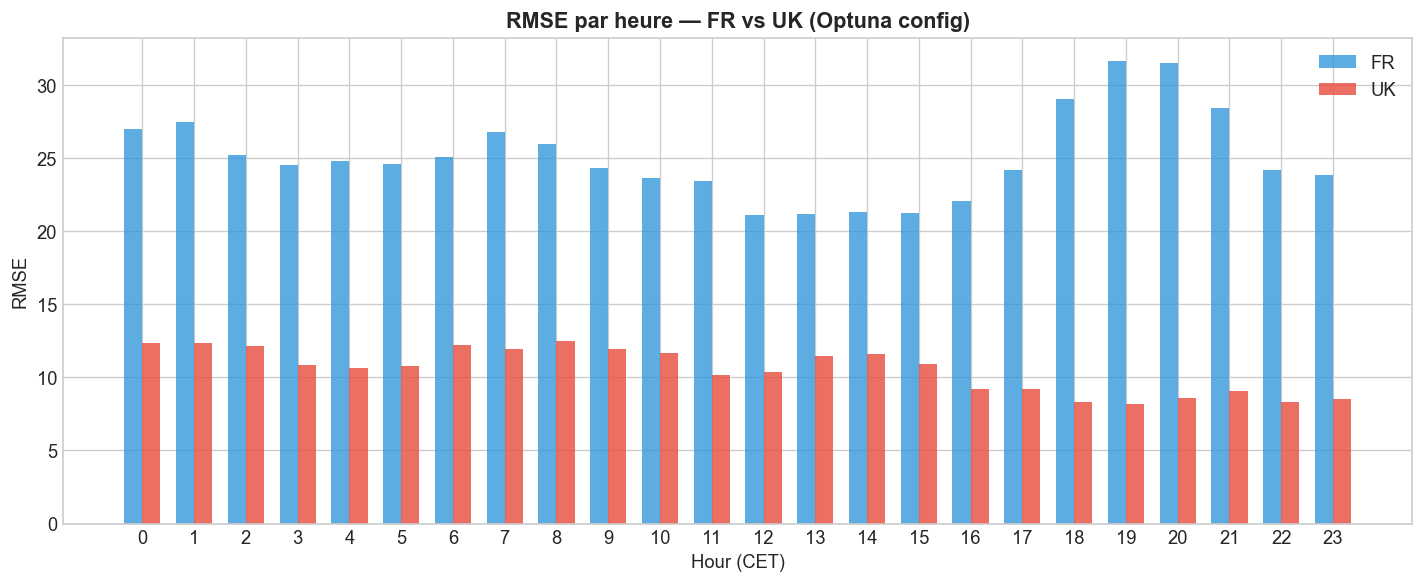

Observations:
  FR: worst hours = h7 (26.8), h19-20 (31.7, 31.5) — morning/evening peaks
  UK: worst hours = h0-2 (12.4, 12.4) — midnight plateau
  FR/UK gap: FR is 2.4x harder than UK


In [12]:
# Hourly RMSE from optuna results (best available breakdown)
fr_hourly = optuna_results['fr_spot']['hourly_rmse']
uk_hourly = optuna_results['uk_spot']['hourly_rmse']

fr_h = [fr_hourly[str(h)] for h in hours]
uk_h = [uk_hourly[str(h)] for h in hours]

fig, ax = plt.subplots(figsize=(12, 5))
width = 0.35
ax.bar([h - width/2 for h in hours], fr_h, width, label='FR', color='#3498db', alpha=0.8)
ax.bar([h + width/2 for h in hours], uk_h, width, label='UK', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Hour (CET)')
ax.set_ylabel('RMSE')
ax.set_title('RMSE par heure — FR vs UK (Optuna config)', fontsize=13, fontweight='bold')
ax.set_xticks(hours)
ax.legend()
plt.tight_layout()
plt.show()

# Key observations
print('Observations:')
print(f'  FR: worst hours = h7 ({fr_h[7]:.1f}), h19-20 ({fr_h[19]:.1f}, {fr_h[20]:.1f}) — morning/evening peaks')
print(f'  UK: worst hours = h0-2 ({uk_h[0]:.1f}, {uk_h[1]:.1f}) — midnight plateau')
print(f'  FR/UK gap: FR is {np.mean(fr_h)/np.mean(uk_h):.1f}x harder than UK')

---
## 5. Diagnostic : Pourquoi UK a régressé

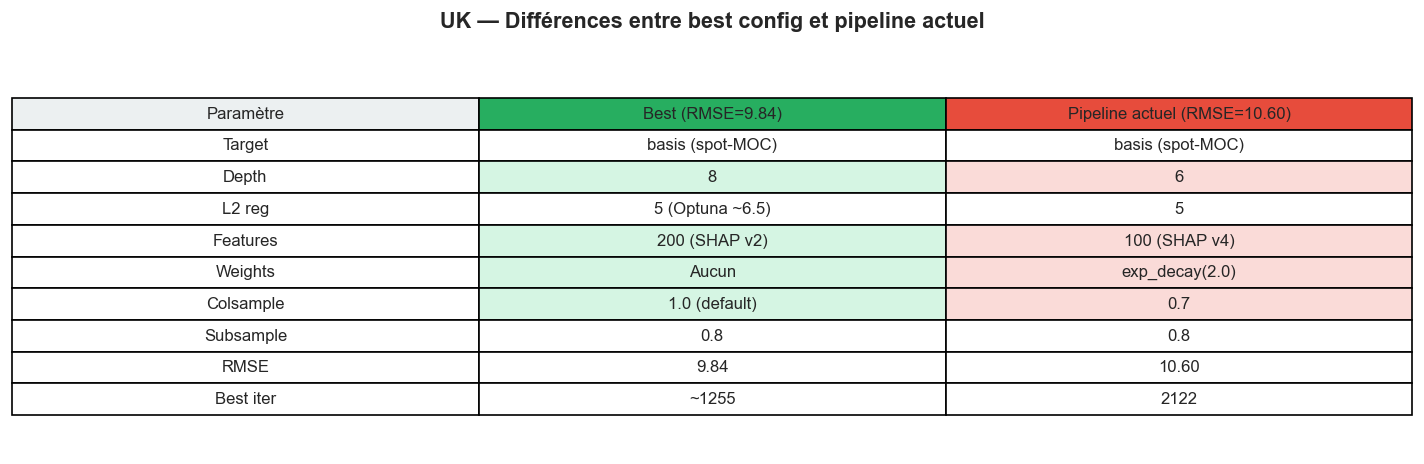


Causes probables de la régression UK:
  1. Weights ajoutés (exp_decay) → pénalise les données anciennes qui étaient utiles
  2. Features réduites (200 → 100) → perte d'information
  3. Depth réduit (8 → 6) → UK a besoin de plus de profondeur
  4. Colsample 0.7 → limite les splits possibles

→ Contrairement à FR (depth 8→3 = gain), UK bénéficie de la profondeur
→ UK et FR ont des dynamiques fondamentalement différentes


In [13]:
# UK regression analysis
uk_comparison = {
    'Paramètre': ['Target', 'Depth', 'L2 reg', 'Features', 'Weights', 'Colsample', 'Subsample',
                  'RMSE', 'Best iter'],
    'Best (9.84)': ['basis (spot-MOC)', '8', '5 (Optuna ~6.5)', '200 (SHAP v2)', 'Aucun',
                    '1.0 (default)', '0.8', '9.84', '~1255'],
    'Pipeline (10.60)': ['basis (spot-MOC)', '6', '5', '100 (SHAP v4)', 'exp_decay(2.0)',
                         '0.7', '0.8', '10.60', '2122'],
}

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')
table = ax.table(
    cellText=list(zip(uk_comparison['Paramètre'],
                      uk_comparison['Best (9.84)'],
                      uk_comparison['Pipeline (10.60)'])),
    colLabels=['Paramètre', 'Best (RMSE=9.84)', 'Pipeline actuel (RMSE=10.60)'],
    cellLoc='center', loc='center',
    colColours=['#ecf0f1', '#27ae60', '#e74c3c'],
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Color the difference rows
diff_rows = [1, 3, 4, 5]  # depth, features, weights, colsample
for row in diff_rows:
    table[row+1, 1].set_facecolor('#d5f5e3')
    table[row+1, 2].set_facecolor('#fadbd8')

ax.set_title('UK — Différences entre best config et pipeline actuel', fontsize=13,
             fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/uk_regression_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCauses probables de la régression UK:')
print('  1. Weights ajoutés (exp_decay) → pénalise les données anciennes qui étaient utiles')
print('  2. Features réduites (200 → 100) → perte d\'information')
print('  3. Depth réduit (8 → 6) → UK a besoin de plus de profondeur')
print('  4. Colsample 0.7 → limite les splits possibles')
print()
print('→ Contrairement à FR (depth 8→3 = gain), UK bénéficie de la profondeur')
print('→ UK et FR ont des dynamiques fondamentalement différentes')

---
## 6. Résumé final

In [14]:
print('=' * 70)
print('  RÉSUMÉ FINAL')
print('=' * 70)
print()
print('  FR (stationary deviation, d=3):  17.30 RMSE (ens+HBC)')
print('  UK (basis, d=6, pipeline):       10.40 RMSE (ens+HBC)')
print('  UK (basis, d=8, old best):        9.84 RMSE (sans HBC!)')
print('  Combined actuel:                 13.85')
print()
print('  PROBLÈME: UK a régressé de 0.56 dans le pipeline')
print('  SOLUTION: Revenir à la config UK d=8/200f/no weights')
print('            + ajouter HBC/ensemble par-dessus')
print('  CIBLE:    Combined ~ 13.40-13.57')
print()
print('  AXES D\'AMÉLIORATION:')
print('  1. UK: Restaurer best config + HP search dédié')
print('  2. FR: HBC = +0.40 → pattern horaire fort à exploiter')
print('  3. FR: h7 et h18-20 = RMSE très élevé → features horaires?')
print('  4. Ensemble: CatBoost + LGB poids à optimiser par heure?')
print('=' * 70)

  RÉSUMÉ FINAL

  FR (stationary deviation, d=3):  17.30 RMSE (ens+HBC)
  UK (basis, d=6, pipeline):       10.40 RMSE (ens+HBC)
  UK (basis, d=8, old best):        9.84 RMSE (sans HBC!)
  Combined actuel:                 13.85

  PROBLÈME: UK a régressé de 0.56 dans le pipeline
  SOLUTION: Revenir à la config UK d=8/200f/no weights
            + ajouter HBC/ensemble par-dessus
  CIBLE:    Combined ~ 13.40-13.57

  AXES D'AMÉLIORATION:
  1. UK: Restaurer best config + HP search dédié
  2. FR: HBC = +0.40 → pattern horaire fort à exploiter
  3. FR: h7 et h18-20 = RMSE très élevé → features horaires?
  4. Ensemble: CatBoost + LGB poids à optimiser par heure?


## 7. Autocorrélation des résidus

In [15]:
import sys, yaml, warnings
import pandas as pd
sys.path.insert(0, '..')
from src.data_loading import load_data, merge_train
from src.feature_engineering import build_features
from catboost import CatBoostRegressor, Pool
warnings.filterwarnings('ignore')

with open('../config.yaml') as f:
    config = yaml.safe_load(f)

x_train, y_train, x_test = load_data('../data/raw')
train = merge_train(x_train, y_train)
train_fe = build_features(train, config)

holdout_start = config['validation']['holdout_start']
mask_val = train_fe['datetime_CET'] >= holdout_start
df_train = train_fe[~mask_val].copy()
df_val = train_fe[mask_val].copy()

# --- FR: stationary target ---
fr_la = train_fe['fr_spot_la']
rm_fr = fr_la.rolling(168, min_periods=24).mean()
n_tr = len(df_train)
rm_fr_tr = rm_fr.iloc[:n_tr].values
rm_fr_va = rm_fr.iloc[n_tr:n_tr+len(df_val)].values
rs_fr_tr = fr_la.rolling(168, min_periods=24).std().iloc[:n_tr].values

y_dev_fr_tr = df_train['fr_spot'].values - rm_fr_tr
y_dev_fr_va = df_val['fr_spot'].values - rm_fr_va
valid_fr_tr = np.isfinite(y_dev_fr_tr)
valid_fr_va = np.isfinite(y_dev_fr_va)

dt = pd.to_datetime(df_train['datetime_CET'])
days_ago = (dt.max() - dt).dt.total_seconds() / 86400
w_fr = np.exp(-2.0 * days_ago.values / 365) / np.clip(np.where(np.isnan(rs_fr_tr**2), 1, rs_fr_tr**2), 1, None)

with open('../outputs/feature_selection_v5_fr.json') as f:
    feat_fr_27 = json.load(f)['features']
feat_fr_28 = feat_fr_27 + ['X_fr_spot_la_roll_168h_mean_x_uk_price_per_mw_7d']
for df in [df_train, df_val]:
    df['X_fr_spot_la_roll_168h_mean_x_uk_price_per_mw_7d'] = (
        df['fr_spot_la_roll_168h_mean'] * df['uk_price_per_mw_7d'])
feat_fr = [f for f in feat_fr_28 if f in df_train.columns]

cb_fr = CatBoostRegressor(
    iterations=15000, learning_rate=0.059, depth=3, l2_leaf_reg=4.42,
    subsample=0.533, colsample_bylevel=0.228, min_child_samples=14,
    random_strength=0.9, random_seed=42, verbose=0, allow_writing_files=False, use_best_model=True)
cb_fr.fit(
    Pool(df_train.loc[df_train.index[valid_fr_tr], feat_fr], y_dev_fr_tr[valid_fr_tr], weight=w_fr[valid_fr_tr]),
    eval_set=Pool(df_val.loc[df_val.index[valid_fr_va], feat_fr], y_dev_fr_va[valid_fr_va]),
    early_stopping_rounds=200, verbose=0)
preds_fr = rm_fr_va + cb_fr.predict(df_val[feat_fr])
resid_fr = df_val['fr_spot'].values - preds_fr

# --- UK: basis target ---
uk_moc_tr = df_train['uk_merit_order_cost'].values
uk_moc_va = df_val['uk_merit_order_cost'].values
y_basis_tr = df_train['uk_spot'].values - uk_moc_tr
y_basis_va = df_val['uk_spot'].values - uk_moc_va
valid_uk_tr = np.isfinite(y_basis_tr)
valid_uk_va = np.isfinite(y_basis_va)

with open('../outputs/uk_feature_research.json') as f:
    feat_uk = [f for f in json.load(f)['confirmed_features'] if f in df_train.columns]

cb_uk = CatBoostRegressor(
    iterations=15000, learning_rate=0.03, depth=8, l2_leaf_reg=5,
    colsample_bylevel=0.8, subsample=0.8, random_seed=42, verbose=0,
    allow_writing_files=False, use_best_model=True)
cb_uk.fit(
    Pool(df_train.loc[df_train.index[valid_uk_tr], feat_uk], y_basis_tr[valid_uk_tr]),
    eval_set=Pool(df_val.loc[df_val.index[valid_uk_va], feat_uk], y_basis_va[valid_uk_va]),
    early_stopping_rounds=200, verbose=0)
preds_uk = uk_moc_va + cb_uk.predict(df_val[feat_uk])
resid_uk = df_val['uk_spot'].values - preds_uk

print(f'FR RMSE: {np.sqrt(np.mean(resid_fr**2)):.2f}, UK RMSE: {np.sqrt(np.mean(resid_uk**2)):.2f}')
print(f'Residuals computed: FR={len(resid_fr)}, UK={len(resid_uk)}')

FR RMSE: 17.18, UK RMSE: 10.19
Residuals computed: FR=3623, UK=3623


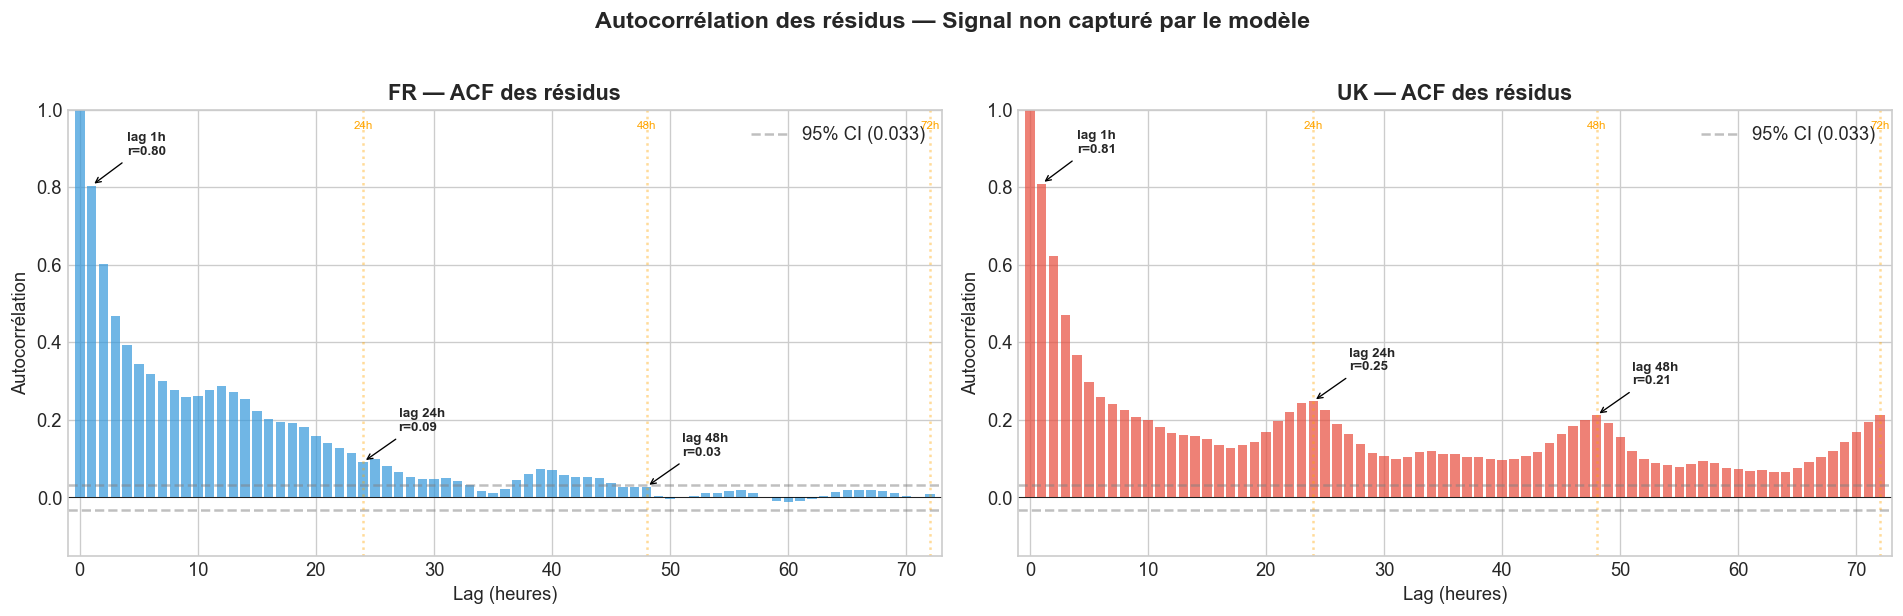


FR: lag-1h r=0.804, lag-24h r=0.091, lag-48h r=0.027
UK: lag-1h r=0.809, lag-24h r=0.248, lag-48h r=0.212

→ r=0.80 a lag-1h = 64% de la variance de l'erreur est predictible
→ Pattern 24h visible = erreurs systematiques par heure (partiellement corrige par HBC)
→ Decroissance lente = "erreurs de regime" qui persistent 3-6h


In [16]:
# --- Autocorrelation plot ---
max_lag = 72  # 3 days

def acf(x, max_lag):
    """Manual ACF computation."""
    x = x - x.mean()
    n = len(x)
    var = np.sum(x**2) / n
    acf_vals = []
    for lag in range(max_lag + 1):
        c = np.sum(x[:n-lag] * x[lag:]) / n / var
        acf_vals.append(c)
    return np.array(acf_vals)

acf_fr = acf(resid_fr, max_lag)
acf_uk = acf(resid_uk, max_lag)
lags = np.arange(max_lag + 1)
ci = 1.96 / np.sqrt(len(resid_fr))  # 95% confidence interval

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, acf_vals, title, color in [
    (axes[0], acf_fr, 'FR', '#3498db'),
    (axes[1], acf_uk, 'UK', '#e74c3c'),
]:
    ax.bar(lags, acf_vals, color=color, alpha=0.7, width=0.8)
    ax.axhline(y=ci, color='gray', linestyle='--', alpha=0.5, label=f'95% CI ({ci:.3f})')
    ax.axhline(y=-ci, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=0, color='black', linewidth=0.5)
    
    # Highlight key lags
    for lag_h in [1, 24, 48]:
        ax.annotate(f'lag {lag_h}h\nr={acf_vals[lag_h]:.2f}',
                    xy=(lag_h, acf_vals[lag_h]),
                    xytext=(lag_h+3, acf_vals[lag_h]+0.08),
                    fontsize=8, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='black', lw=0.8))
    
    ax.set_xlabel('Lag (heures)')
    ax.set_ylabel('Autocorrélation')
    ax.set_title(f'{title} — ACF des résidus', fontsize=13, fontweight='bold')
    ax.set_xlim(-1, max_lag + 1)
    ax.set_ylim(-0.15, 1.0)
    ax.legend(loc='upper right')
    
    # Add vertical lines at 24h intervals
    for d in [24, 48, 72]:
        if d <= max_lag:
            ax.axvline(x=d, color='orange', linestyle=':', alpha=0.4)
            ax.text(d, 0.95, f'{d}h', ha='center', fontsize=7, color='orange')

plt.suptitle('Autocorrélation des résidus — Signal non capturé par le modèle',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/residual_acf.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nFR: lag-1h r={acf_fr[1]:.3f}, lag-24h r={acf_fr[24]:.3f}, lag-48h r={acf_fr[48]:.3f}')
print(f'UK: lag-1h r={acf_uk[1]:.3f}, lag-24h r={acf_uk[24]:.3f}, lag-48h r={acf_uk[48]:.3f}')
print(f'\n→ r=0.80 a lag-1h = 64% de la variance de l\'erreur est predictible')
print(f'→ Pattern 24h visible = erreurs systematiques par heure (partiellement corrige par HBC)')
print(f'→ Decroissance lente = "erreurs de regime" qui persistent 3-6h')

## 8. Prédictions vs Valeurs Réelles (validation set)

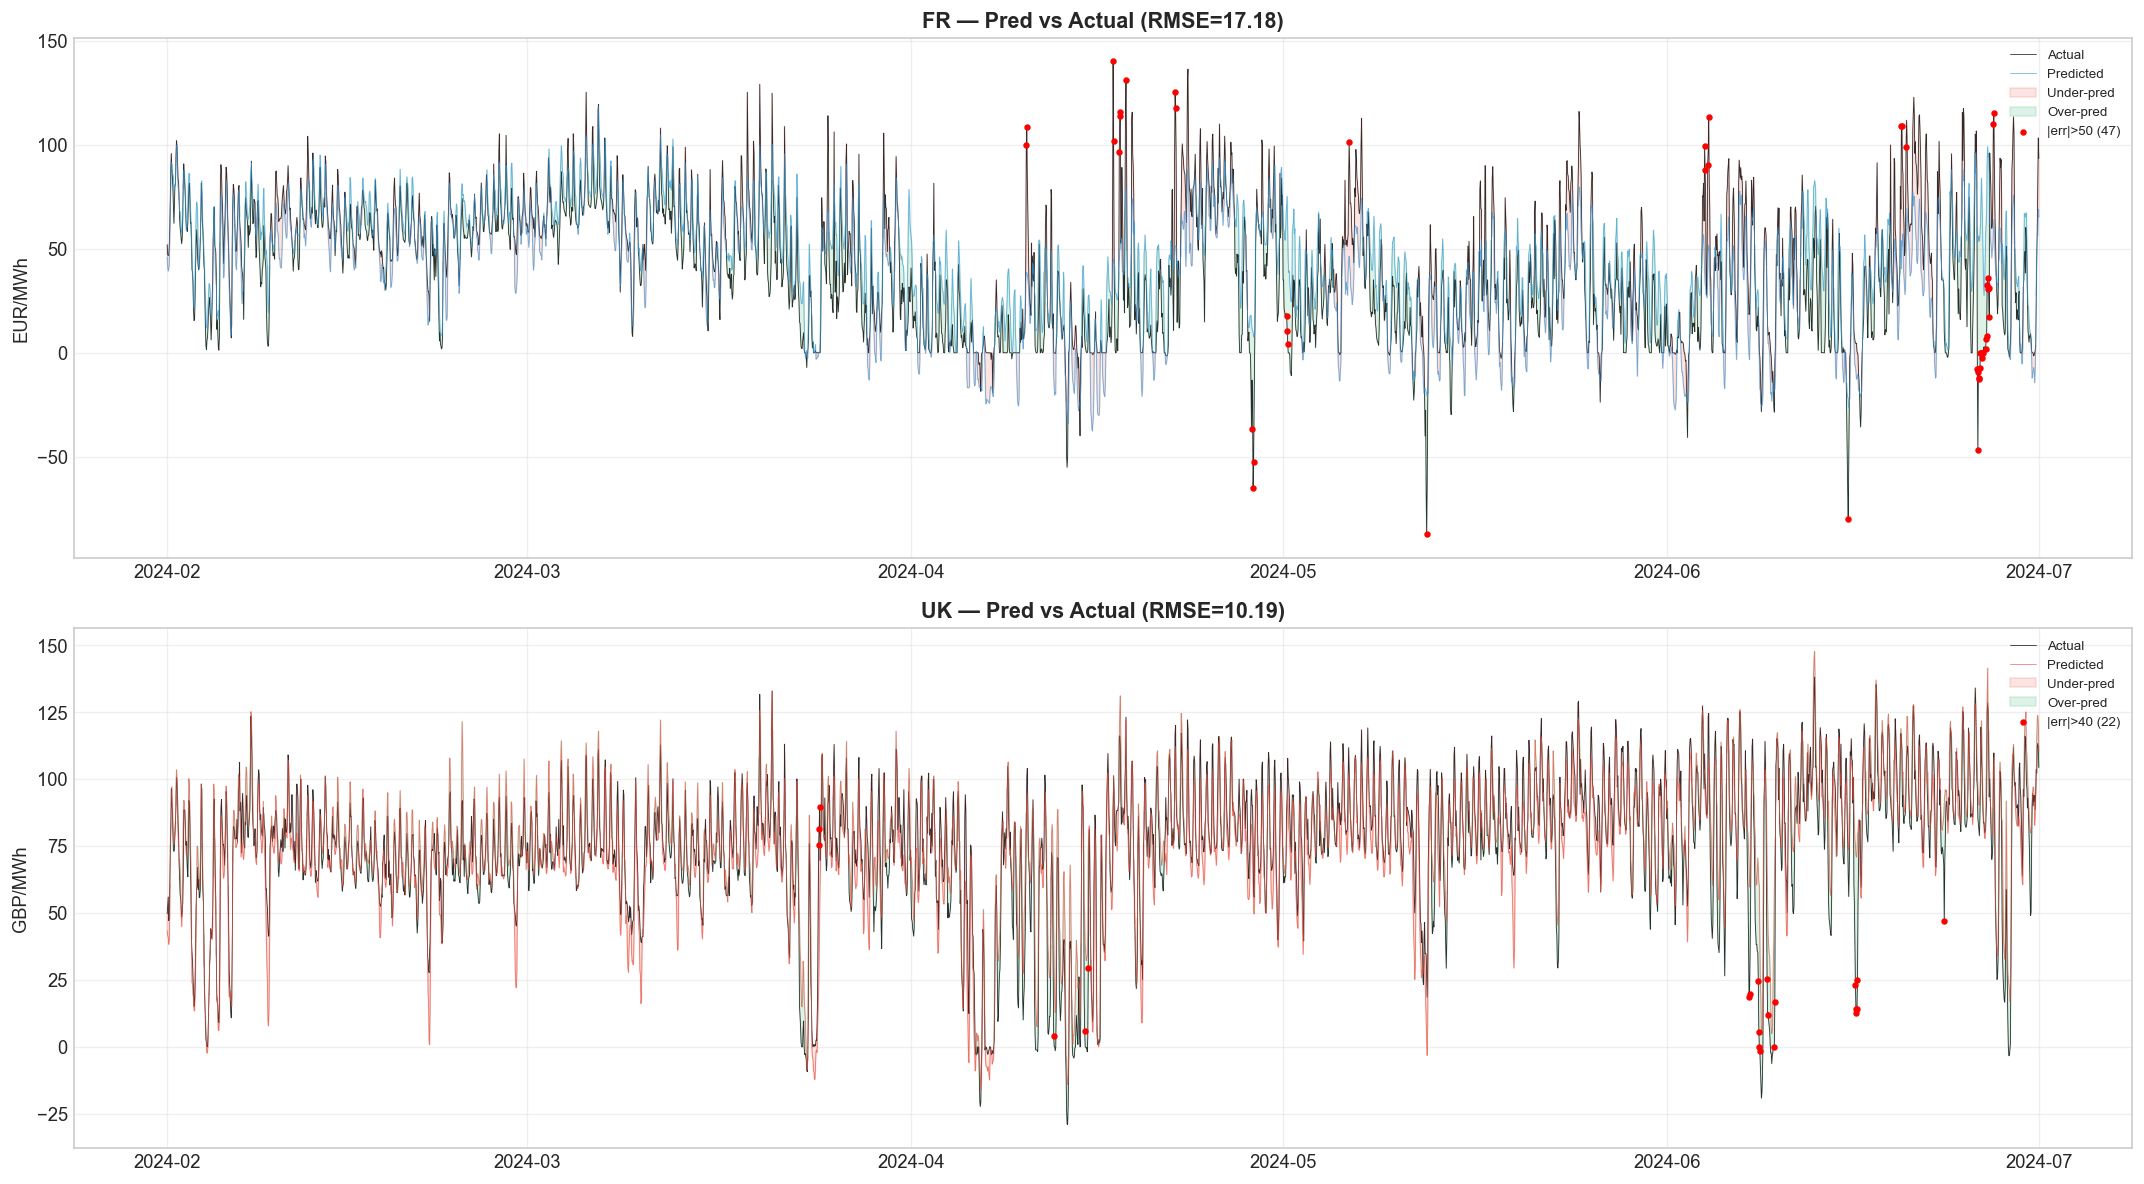


RMSE par mois:
      Mois       FR       UK
  --------------------------
   2024-02     9.23     7.29
   2024-03    12.68     8.64
   2024-04    19.48    11.63
   2024-05    17.79     8.43
   2024-06    23.04    13.64
     TOTAL    17.18    10.19


In [17]:
# --- Pred vs Actual time series ---
dates_va = pd.to_datetime(df_val['datetime_CET'])
fr_actual = df_val['fr_spot'].values
uk_actual = df_val['uk_spot'].values

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=False)

# --- FR ---
ax = axes[0]
ax.plot(dates_va, fr_actual, color='black', linewidth=0.5, alpha=0.8, label='Actual')
ax.plot(dates_va, preds_fr, color='#3498db', linewidth=0.5, alpha=0.7, label='Predicted')
# Error fill
ax.fill_between(dates_va, preds_fr, fr_actual,
                where=(fr_actual > preds_fr), color='#e74c3c', alpha=0.15, label='Under-pred')
ax.fill_between(dates_va, preds_fr, fr_actual,
                where=(fr_actual < preds_fr), color='#27ae60', alpha=0.15, label='Over-pred')

# Mark worst errors (|error| > 50 EUR)
big_err = np.abs(resid_fr) > 50
if big_err.any():
    ax.scatter(dates_va[big_err], fr_actual[big_err], color='red', s=8, zorder=5, label=f'|err|>50 ({big_err.sum()})')

ax.set_ylabel('EUR/MWh')
ax.set_title(f'FR — Pred vs Actual (RMSE={np.sqrt(np.mean(resid_fr**2)):.2f})', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# --- UK ---
ax = axes[1]
ax.plot(dates_va, uk_actual, color='black', linewidth=0.5, alpha=0.8, label='Actual')
ax.plot(dates_va, preds_uk, color='#e74c3c', linewidth=0.5, alpha=0.7, label='Predicted')
ax.fill_between(dates_va, preds_uk, uk_actual,
                where=(uk_actual > preds_uk), color='#e74c3c', alpha=0.15, label='Under-pred')
ax.fill_between(dates_va, preds_uk, uk_actual,
                where=(uk_actual < preds_uk), color='#27ae60', alpha=0.15, label='Over-pred')

big_err_uk = np.abs(resid_uk) > 40
if big_err_uk.any():
    ax.scatter(dates_va[big_err_uk], uk_actual[big_err_uk], color='red', s=8, zorder=5, label=f'|err|>40 ({big_err_uk.sum()})')

ax.set_ylabel('GBP/MWh')
ax.set_title(f'UK — Pred vs Actual (RMSE={np.sqrt(np.mean(resid_uk**2)):.2f})', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/pred_vs_actual_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Monthly error breakdown ---
months_va = dates_va.dt.to_period('M')
print('\nRMSE par mois:')
print(f'  {"Mois":>8s}  {"FR":>7s}  {"UK":>7s}')
print('  ' + '-' * 26)
for m in sorted(months_va.unique()):
    mask = months_va == m
    fr_m = np.sqrt(np.mean(resid_fr[mask]**2))
    uk_m = np.sqrt(np.mean(resid_uk[mask]**2))
    print(f'  {str(m):>8s}  {fr_m:7.2f}  {uk_m:7.2f}')
print(f'  {"TOTAL":>8s}  {np.sqrt(np.mean(resid_fr**2)):7.2f}  {np.sqrt(np.mean(resid_uk**2)):7.2f}')